In [65]:
import json
import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
def load_output(path, condition, eval_mode, meta_df):
    with open(path) as f:
        obj = json.load(f)

    # Collect ALL lists from top-level dict (e.g., "correct", "incorrect")
    data = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, list):
                for ex in v:
                    ex["_bucket"] = k
                    data.append(ex)
    elif isinstance(obj, list):
        data = obj
    else:
        raise ValueError(f"Unexpected JSON type {type(obj)} in {path}")

    if not data:
        raise ValueError(f"No examples found in {path}")

    rows = []
    for ex in data:
        qtext = ex.get("question", "")

        # Count answer options
        n_options = len(re.findall(r"\([A-E]\)", qtext))

        qid = str(ex.get("question_id"))
        qid_no0 = qid.lstrip("0") or "0"

        rows.append({
            "question_id": qid,
            "question_id_no0": qid_no0,
            "pred": ex.get("parsed_ans"),
            "gt": ex.get("ground_truth"),
            "correct": ex.get("parsed_ans") == ex.get("ground_truth"),
            "n_options": n_options,
            "condition": condition,
            "eval_mode": eval_mode,
            "bucket": ex.get("_bucket", None)
        })

    df = pd.DataFrame(rows)

    # ---- MERGE GRADE + SUBJECT ----
    df = df.merge(
        meta_df[["question_id_no0", "grade", "subject"]],
        on="question_id_no0",
        how="left"
    )

    def grade_bucket(g):
        if pd.isna(g):
            return "unknown"
        g = int(g)
        if 2 <= g <= 4:
            return "G2–4"
        if 5 <= g <= 8:
            return "G5–8"
        return "other"

    df["grade_bucket"] = df["grade"].apply(grade_bucket)


    return df


In [87]:

BASE = Path("/Users/katarina/Documents/Studing/Masters/Semester1/DeepLearning/project/")  # adjust if needed
dfs = []

for condition_dir in BASE.iterdir():
    if not condition_dir.is_dir():
        continue

    condition = condition_dir.name

    for eval_dir in condition_dir.iterdir():
        if not eval_dir.is_dir():
            continue

        eval_mode = eval_dir.name
        out_file = eval_dir / "output.jsonl"

        if out_file.exists():
            dfs.append(
                load_output(out_file, condition, eval_mode, meta)
            )

df_all = pd.concat(dfs, ignore_index=True)



In [89]:
df_all.head()

,question_id,question_id_no0,pred,gt,correct,n_options,condition,eval_mode,bucket,grade,subject
0,23,23,B,B,True,2,AE,with_CoT,correct,5,natural science
1,46,46,C,C,True,3,AE,with_CoT,correct,4,natural science
2,85,85,A,A,True,3,AE,with_CoT,correct,5,natural science
3,86,86,B,B,True,3,AE,with_CoT,correct,4,natural science
4,87,87,A,A,True,2,AE,with_CoT,correct,3,natural science


In [ ]:
df_all.groupby(["condition", "eval_mode", "grade"]).size()

condition  eval_mode  grade
A          no_CoT     2        107
                      3        228
                      4        237
                      5        175
                      6        127
                              ... 
LEA        with_CoT   5        175
                      6        127
                      7        166
                      8        163
                      12         5
Length: 72, dtype: int64

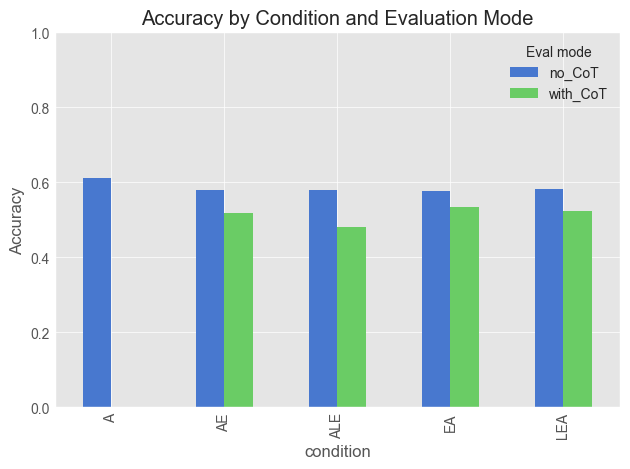

In [69]:
acc = (
    df_all
    .groupby(["condition", "eval_mode"])["correct"]
    .mean()
    .unstack()
)

acc.plot(kind="bar")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy by Condition and Evaluation Mode")
plt.legend(title="Eval mode")
plt.tight_layout()
plt.show()


In [70]:
acc

eval_mode,no_CoT,with_CoT
condition,,
A,0.611755,NaN
AE,0.579470,0.518212
ALE,0.579470,0.480960
EA,0.576159,0.533113
LEA,0.581126,0.524007


In [71]:
opt_acc = (
    df_all
    .groupby(["n_options", "condition", "eval_mode"])["correct"]
    .mean()
    .reset_index()
)


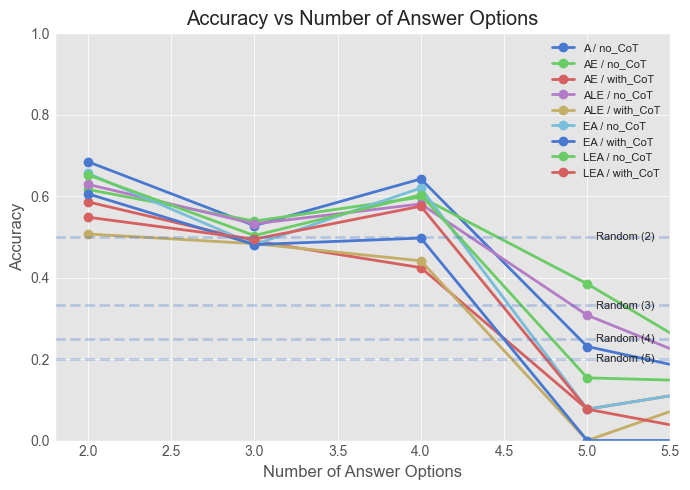

In [72]:
plt.figure(figsize=(7,5))

# ---- YOUR REAL DATA (example) ----
for (cond, mode), sub in opt_acc.groupby(["condition", "eval_mode"]):
    plt.plot(
        sub["n_options"],
        sub["correct"],
        marker="o",
        label=f"{cond} / {mode}"
    )

# ---- RANDOM BASELINES ----
baseline = {2: 0.5, 3: 1/3, 4: 0.25, 5: 0.2}

for n, b in baseline.items():
    plt.axhline(b, linestyle="--", alpha=0.3)

# ---- AXIS CONTROL (THIS IS THE KEY) ----
plt.xlim(1.8, 5.5)
plt.ylim(0, 1)

# ---- LABEL BASELINES ----
plt.text(5.05, 0.50, "Random (2)", fontsize=8, va="center")
plt.text(5.05, 0.33, "Random (3)", fontsize=8, va="center")
plt.text(5.05, 0.25, "Random (4)", fontsize=8, va="center")
plt.text(5.05, 0.20, "Random (5)", fontsize=8, va="center")

plt.xlabel("Number of Answer Options")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Answer Options")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


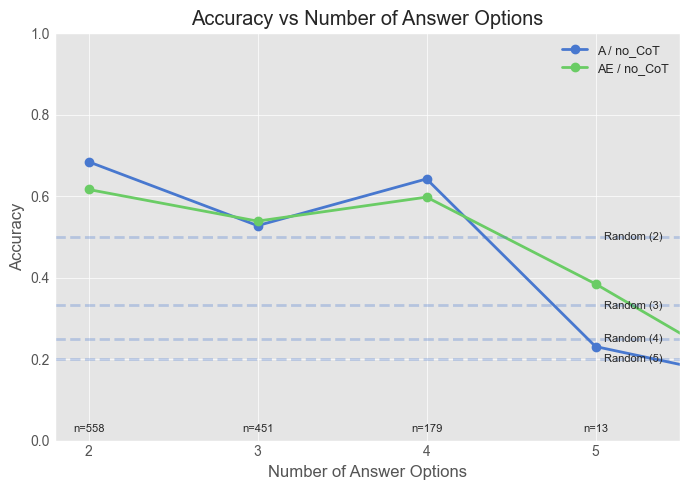

In [82]:
plt.figure(figsize=(7,5))

# ---- FILTER TO ONLY WHAT YOU WANT ----
sub_opt = opt_acc[
    ((opt_acc["condition"] == "AE") & (opt_acc["eval_mode"] == "no_CoT")) |
    ((opt_acc["condition"] == "A")   & (opt_acc["eval_mode"] == "no_CoT"))
]

# ---- PLOT REAL DATA ----
for cond, sub in sub_opt.groupby("condition"):
    plt.plot(
        sub["n_options"],
        sub["correct"],
        marker="o",
        label=f"{cond} / no_CoT"
    )

# ---- RANDOM BASELINES ----
baseline = {2: 0.5, 3: 1/3, 4: 0.25, 5: 0.2}
for b in baseline.values():
    plt.axhline(b, linestyle="--", alpha=0.3)

# ---- SAMPLE SIZE ----
counts = (
    df_all[
        (df_all["condition"] == "AE") &
        (df_all["eval_mode"] == "no_CoT")
    ]["n_options"]
    .value_counts()
)

for x in [2, 3, 4, 5]:
    if x in counts:
        plt.text(x, 0.02, f"n={counts[x]}", ha="center", fontsize=8)


# ---- AXIS CONTROL ----
plt.xlim(1.8, 5.5)
plt.ylim(0, 1)
plt.xticks([2, 3, 4, 5])   # integers only

# ---- LABEL BASELINES ----
plt.text(5.05, 0.50, "Random (2)", fontsize=8, va="center")
plt.text(5.05, 0.33, "Random (3)", fontsize=8, va="center")
plt.text(5.05, 0.25, "Random (4)", fontsize=8, va="center")
plt.text(5.05, 0.20, "Random (5)", fontsize=8, va="center")

# ---- LABELS & TITLE ----
plt.xlabel("Number of Answer Options")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Answer Options")
plt.legend(fontsize=9)

plt.tight_layout()
plt.style.use("seaborn-v0_8-muted")
#plt.style.use("ggplot")
plt.show()


In [74]:
summary = (
    df_all
    .groupby(["condition", "eval_mode", "n_options"])["correct"]
    .mean()
    .reset_index()
)

summary


,condition,eval_mode,n_options,correct
0,A,no_CoT,2,0.684588
1,A,no_CoT,3,0.527716
2,A,no_CoT,4,0.642458
3,A,no_CoT,5,0.230769
4,A,no_CoT,6,0.142857
5,AE,no_CoT,2,0.616487
6,AE,no_CoT,3,0.538803
7,AE,no_CoT,4,0.597765
8,AE,no_CoT,5,0.384615
9,AE,no_CoT,6,0.142857


In [75]:
def radar_plot(ax, data, title):
    """
    data: dict {label -> list of values in order of option_counts}
    """
    option_counts = sorted(next(iter(data.values())).__len__() and range(len(next(iter(data.values())))))
    # we'll pass values already aligned, so compute angles from length
    n = len(next(iter(data.values())))
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # label axes (we'll set these outside to match 2/3/4/5)
    ax.set_title(title, y=1.08)

    for label, vals in data.items():
        vals = list(vals)
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=label)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_ylim(0, 1)
    ax.grid(True)


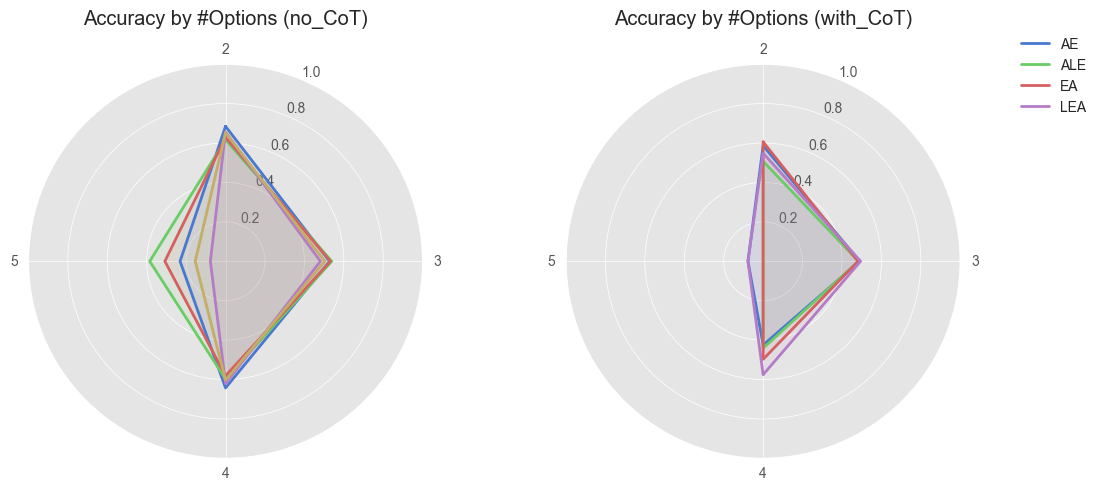

In [76]:
# Ensure consistent axes (2,3,4,5). If some are missing, we’ll keep NaN and skip.
opt_axis = [2, 3, 4, 5]

fig, axes = plt.subplots(1, 2, subplot_kw=dict(polar=True), figsize=(12, 5))

for ax, mode in zip(axes, ["no_CoT", "with_CoT"]):
    sub = summary[summary["eval_mode"] == mode].copy()

    # pivot into rows=condition, cols=n_options
    pv = sub.pivot_table(index="condition", columns="n_options", values="correct")

    # reorder cols and keep only desired option counts
    pv = pv.reindex(columns=opt_axis)

    # Build dict for plotting; drop conditions with all-NaN (e.g., missing with_CoT for A)
    data = {}
    for cond in pv.index:
        vals = pv.loc[cond].values.astype(float)
        if np.all(np.isnan(vals)):
            continue
        # replace NaN with 0 for plotting (or you can skip those axes)
        vals = np.nan_to_num(vals, nan=0.0)
        data[cond] = vals

    radar_plot(ax, data, title=f"Accuracy by #Options ({mode})")
    # Axis labels
    n = len(opt_axis)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    ax.set_xticks(angles)
    ax.set_xticklabels([str(x) for x in opt_axis])

axes[1].legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()
